# 09g — CDP-style net-zero commitment tracking

This notebook builds "track record vs. target vs. net-zero-emissions
(NZE) scenario" comparison charts for illustrative issuers, in the
style of a CDP or Climate Action Tracker corporate net-zero-commitment
review.

**Data-blocked analyses:** two further issuer track-record charts would
need a multi-year (2013-2030), multi-issuer, sector-classified panel
with historical emissions, stated targets, and NZE scenario paths per
issuer, filtered down per issuer. That panel isn't available here — a
single-year 2020 Scope 1/2/3 snapshot for a handful of companies exists
but has no multi-year track record, no sector classification, and no
targets/NZE columns, so it can't substitute. Both charts are omitted
rather than built with placeholder data. The three issuer charts below
are fully self-contained (hardcoded illustrative multi-year series) and
are built as normal.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import PchipInterpolator

plt.rcParams["figure.dpi"] = 100

## Shared chart builder

All three issuer charts share an identical structure: five synthetic
multi-year series are reduced to four labeled curves — **track record**
(actual history through 2020), **2020 trend** (a straight-line
extrapolation from the 2020 value using the slope implied by the two
points just after it), **targets**, and **NZE scenario** (the 4th and
5th raw series, used in full) — each smoothed with a shape-preserving
PCHIP spline between its own actual (year, value) data points, which are
also marked. Factored into one helper here since the pattern repeats
identically 3 times.


In [2]:
def tale_chart(ax, raw, ylim, yticks):
    raw = np.asarray(raw, dtype=float)
    data = raw.T
    data = data / data[0, :]
    nobs = data.shape[0]
    year = np.arange(2013, 2013 + nobs)

    track_record = data[:, 0].copy()
    track_record[year > 2020] = np.nan

    trend_base = data[:, 0].copy()
    trend_base[year < 2020] = np.nan

    targets = data[:, 3].copy()
    nze = data[:, 4].copy()

    series = {"Track record": track_record, "2020 trend": trend_base,
              "Targets": targets, "NZE scenario": nze}
    colours = {"Track record": "tab:blue", "2020 trend": "tab:red",
               "Targets": "tab:purple", "NZE scenario": "tab:green"}
    styles = {"Track record": "-", "2020 trend": "-",
              "Targets": "--", "NZE scenario": "-."}
    markers = {"Track record": "o", "2020 trend": "o",
               "Targets": "d", "NZE scenario": "p"}

    ax.axvline(2020, linestyle="--", color="black", linewidth=1.5)

    for name, y in series.items():
        mask = ~np.isnan(y)
        x, yv = year[mask], y[mask]
        if name == "2020 trend":
            # straight-line extrapolation from the 2020 value using the
            # slope implied by the next two points
            beta1 = yv[2] - yv[1]
            x_line = np.arange(2020, 2031)
            y_line = yv[0] + beta1 * (x_line - 2020)
            ax.plot(x_line, y_line, styles[name], color=colours[name], linewidth=1.5)
            ax.plot(x[1:], yv[1:], markers[name], color=colours[name], markersize=5,
                     linestyle="none", label=name)
        else:
            x_fine = np.linspace(x[0], x[-1], 400)
            y_fine = PchipInterpolator(x, yv)(x_fine)
            ax.plot(x_fine, y_fine, styles[name], color=colours[name], linewidth=1.5)
            ax.plot(x, yv, markers[name], color=colours[name], markersize=5,
                     linestyle="none", label=name)

    ax.set_xlim(2012, 2030)
    ax.set_xticks(range(2012, 2031, 2))
    ax.set_ylim(*ylim)
    ax.set_yticks(yticks)
    ax.spines[["top", "right"]].set_visible(False)

## 1. Issuer A track record


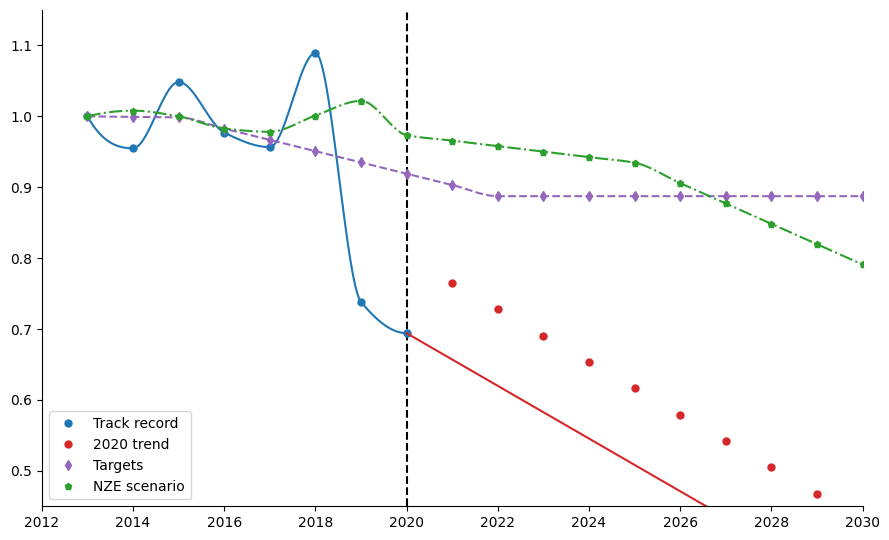

In [3]:
raw1 = [
    [36925464, 35262211, 38713064, 36080871, 35323793, 40228437, 27263509, 25633085, 28254637,
     26882599.8333335, 25510562.6666665, 24138525.5, 22766488.3333335, 21394451.1666665,
     20022414, 18650376.8333335, 17278339.6666665, 15906302.5],
    [36925464, 35262211, 38713064, 36080871, 35323793, 40228437, 27263509, 32479237.8571429,
     31677713.4285715, 30876189, 30074664.5714288, 29273140.1428573, 28471615.7142859,
     27670091.2857144, 26868566.8571429, 26067042.4285717, 25265518.0000002, 24463993.5714288],
    [36925464, 35262211, 38713064, 36080871, 35323793, 40228437, 38495715.1333294,
     38897641.3619009, 39299567.5904725, 39701493.819044, 40103420.0476155, 40505346.2761871,
     40907272.5047586, 41309198.7333301, 41711124.9619017, 42113051.1904732, 42514977.4190447,
     42916903.6476163],
    [36925464, 36899202.9, 36872941.8, 36286530.4, 35700119, 35113707.6, 34527296.2,
     33940884.8, 33354473.4, 32768062, 32768062, 32768062, 32768062, 32768062, 32768062,
     32768062, 32768062, 32768062],
    [36925464, 37222224.3306544, 36925464, 36289549.0057405, 36119971.673938,
     36967858.3329506, 37730956.326062, 35950394.3421355, 35662112.8780712, 35373831.4140069,
     35085549.9499426, 34797268.4858783, 34508987.021814, 33449128.6980482, 32389270.3742824,
     31329412.0505166, 30269553.7267509, 29209695.4029851],
]

fig, ax = plt.subplots(figsize=(9, 5.5))
tale_chart(ax, raw1, ylim=(0.45, 1.15), yticks=np.arange(0.5, 1.11, 0.1))
ax.legend(fontsize=10, loc="lower left")
plt.tight_layout()
plt.show()

## 2. Issuer B track record


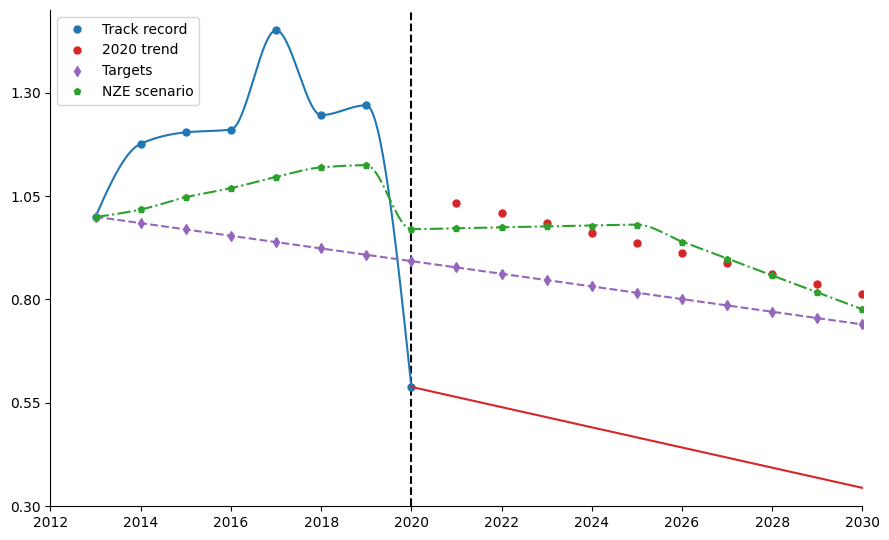

In [4]:
raw2 = [
    [1, 1.17665947557793, 1.20425549462423, 1.21084240049595, 1.45088368072979, 1.24593221686152,
     1.26967157622669, 0.588548484917646, 1.03352620249783, 1.00912109945751, 0.984715996417192,
     0.960310893376866, 0.935905790336548, 0.911500687296222, 0.887095584255904, 0.862690481215586,
     0.83828537817526, 0.813880275134942],
    [1, 1.17665947557793, 1.20425549462423, 1.21084240049595, 1.45088368072979, 1.24593221686152,
     1.26967157622669, 1.39320474883855, 1.43585433445829, 1.47850392007804, 1.52115350569778,
     1.56380309131753, 1.60645267693726, 1.64910226255702, 1.69175184817675, 1.7344014337965,
     1.77705101941625, 1.81970060503599],
    [1, 1.17665947557793, 1.20425549462423, 1.21084240049595, 1.45088368072979, 1.24593221686152,
     1.42065427194481, 1.47948057496293, 1.53830687798104, 1.59713318099916, 1.65595948401728,
     1.71478578703539, 1.77361209005351, 1.83243839307163, 1.89126469608975, 1.95009099910786,
     2.00891730212598, 2.0677436051441],
    [1, 0.984688855119943, 0.969377710239886, 0.95406656535983, 0.938755420479773,
     0.923444275599716, 0.908133130719659, 0.892821985839602, 0.877510840959546,
     0.862199696079489, 0.846888551199432, 0.831577406319375, 0.816266261439318,
     0.800955116559262, 0.785643971679205, 0.770332826799148, 0.755021681919091, 0.739710537039034],
    [1, 1.01763907734057, 1.04748982360923, 1.06919945725916, 1.09633649932157, 1.11940298507463,
     1.12483039348711, 0.970149253731343, 0.972320217096336, 0.97449118046133, 0.976662143826323,
     0.978833107191316, 0.981004070556309, 0.940027137042062, 0.899050203527816, 0.858073270013568,
     0.817096336499322, 0.776119402985075],
]

fig, ax = plt.subplots(figsize=(9, 5.5))
tale_chart(ax, raw2, ylim=(0.3, 1.5), yticks=np.arange(0.3, 1.51, 0.25))
ax.legend(fontsize=10, loc="upper left")
plt.tight_layout()
plt.show()

## 3. Issuer C track record


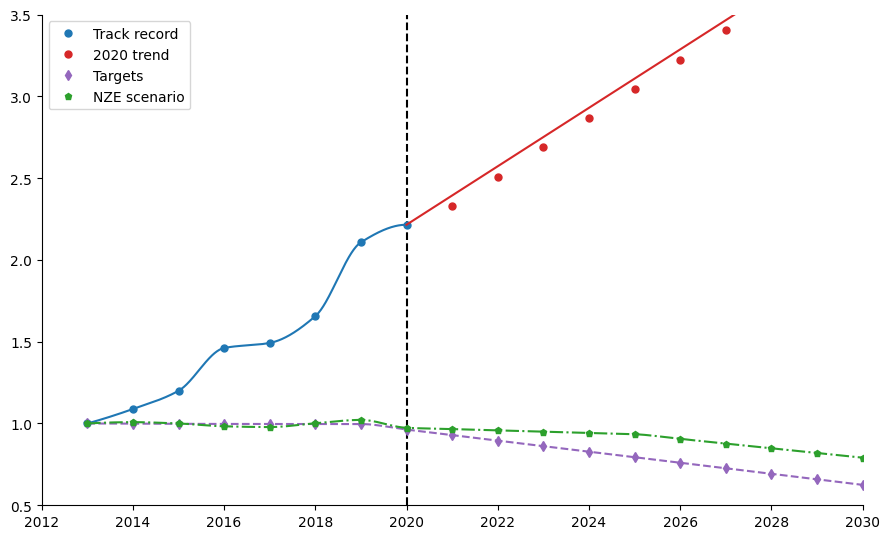

In [5]:
raw3 = [
    [1, 1.08841995940141, 1.19992446773356, 1.46136052494925, 1.49247037718926, 1.65606594911014,
     2.10744639569466, 2.21498371335505, 2.33113137724996, 2.50969747809903, 2.6882635789481,
     2.86682967979717, 3.04539578064624, 3.22396188149526, 3.40252798234433, 3.5810940831934,
     3.75966018404247, 3.93822628489154],
    [1, 1.08841995940141, 1.19992446773356, 1.46136052494925, 1.49247037718926, 1.65606594911014,
     2.10744639569466, 2.10798067857667, 2.27762985986084, 2.44727904114505, 2.61692822242921,
     2.78657740371342, 2.95622658499758, 3.12587576628179, 3.29552494756596, 3.46517412885017,
     3.63482331013433, 3.80447249141854],
    [1, 1.08841995940141, 1.19992446773356, 1.46136052494925, 1.49247037718926, 1.65606594911014,
     1.79176525200997, 1.92759145361365, 2.06341765521733, 2.19924385682101, 2.33507005842469,
     2.47089626002837, 2.60672246163205, 2.74254866323573, 2.87837486483946, 3.01420106644314,
     3.15002726804682, 3.2858534696505],
    [1, 0.998769121465326, 0.997538242930652, 0.997294830760515, 0.997051418590379,
     0.996808006420243, 0.996564594250106, 0.962779955624793, 0.928995316999481,
     0.895210678374168, 0.861426039748855, 0.827641401123542, 0.79385676249823,
     0.760072123872917, 0.726287485247604, 0.692502846622291, 0.658718207996979, 0.624933569371666],
    [1, 1.00803673938002, 1, 0.982778415614236, 0.978185993111366, 1.00114810562572,
     1.02181400688863, 0.973593570608496, 0.965786452353616, 0.957979334098737,
     0.950172215843857, 0.942365097588978, 0.934557979334099, 0.905855338691159,
     0.87715269804822, 0.848450057405281, 0.819747416762342, 0.791044776119403],
]

fig, ax = plt.subplots(figsize=(9, 5.5))
tale_chart(ax, raw3, ylim=(0.5, 3.5), yticks=np.arange(0.5, 3.51, 0.5))
ax.legend(fontsize=10, loc="upper left")
plt.tight_layout()
plt.show()